In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

from seaborn import color_palette
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Experimentation
- Slidding window with a size of 2000 observations
- Retrain every 21 days
- Prediction horizon: 7 days
- 30 day exponential moving avg done to the adjusted close, provided as the target variable
- feature variables: 15 lags

In [72]:
# get the predictions located in the folders and plot the prediction vs actuals
portfolio_assets = [
        'ACM',
        'OSK',
        'PATH',
        'RGLD',
        'AAAU',
        'CIBR',
        'IBIT',
        'ITA',
        'SGDM',
        'USO',
        'USXF',
        'XHE'
    ]
# load the data
assets = {}
for ticker in portfolio_assets:
    try:
        file_path = f"data/results/{ticker}/auto_kernel/{ticker}_results.parquet"

        df = pd.read_parquet(file_path)
        # print(df.head())
        # transform the predictions and the actuals
        df['actual'] = df['actual_value'].apply(lambda x: x[0][0])
        df['predicted'] = df['prediction'].apply(lambda x: x[0])
        df['predicted upper bound'] = df['predicted'] + ((df['std'] + 0.1) * 3)
        df['predicted lower bound'] = df['predicted'] - ((df['std'] + 0.1) * 3)
        # add a 14 exponential moving average day prediction mean
        df['predicted avg'] = df['predicted'].rolling(window=5).mean()
        df['predicted avg upper bound'] = df['predicted avg'] + ((df['std'] + 0.1) * 3)
        df['predicted avg lower bound'] = df['predicted avg'] - ((df['std'] + 0.1) * 3)
        assets[ticker] = df
    except Exception as e:
        print(f"Error reading {ticker}: {e}")


Error reading PATH: 'actual_value'
Error reading AAAU: 'actual_value'
Error reading IBIT: 'actual_value'
Error reading USXF: 'actual_value'


In [73]:
# get the prediction metrics
# calculate teh regression metrics
metrics_data = []
for key in assets.keys():
    mse = mean_squared_error(assets[key]['actual'], assets[key]['predicted'])
    mae = mean_absolute_error(assets[key]['actual'], assets[key]['predicted'])
    r2 = r2_score(assets[key]['actual'], assets[key]['predicted'])

    mse_avg = mean_squared_error(assets[key]['actual'].values[14:], assets[key]['predicted avg'].values[14:])
    rmse_avg = np.sqrt(mse_avg)
    mae_avg = mean_absolute_error(assets[key]['actual'].values[14:], assets[key]['predicted avg'].values[14:])
    r2_avg = r2_score(assets[key]['actual'].values[14:], assets[key]['predicted avg'].values[14:])
    print(f"Ticker: {key}->\tMSE: {mse}, MAE: {mae}, R2: {r2}")
    print(f"Ticker AVG: {key}->\tMSE: {mse_avg}, MAE: {mae_avg}, R2: {r2_avg}, RMSE: {rmse_avg}")
    print(f"\n")

# assets['OSK']

Ticker: ACM->	MSE: 3.651073056602366, MAE: 0.7843788286831196, R2: 0.9954000665850039
Ticker AVG: ACM->	MSE: 3.06767883048087, MAE: 0.6435698448500365, R2: 0.9961337204898386, RMSE: 1.7514790408340233


Ticker: OSK->	MSE: 1.9778424064452291, MAE: 1.0781008419574076, R2: 0.9962960057023738
Ticker AVG: OSK->	MSE: 0.8468716012433848, MAE: 0.6970454292313616, R2: 0.9983872782598947, RMSE: 0.9202562693312036


Ticker: RGLD->	MSE: 4.763943196603021, MAE: 1.4184516859888106, R2: 0.9952679709759596
Ticker AVG: RGLD->	MSE: 2.972816413243166, MAE: 1.0192143546690688, R2: 0.9969848531469758, RMSE: 1.7241857246953316


Ticker: CIBR->	MSE: 0.3338215480901679, MAE: 0.46613032986941155, R2: 0.996454889144306
Ticker AVG: CIBR->	MSE: 0.23071443765337388, MAE: 0.3681788632853075, R2: 0.9974584129799755, RMSE: 0.48032742754643304


Ticker: ITA->	MSE: 1.3422896812058702, MAE: 0.7439918453545155, R2: 0.9986967285854206
Ticker AVG: ITA->	MSE: 0.8060385059481089, MAE: 0.5736138712946605, R2: 0.99921166769314

In [74]:
assets[key].tail()

,date,actual_value,prediction,std,best_kernel,best_alpha,retrain,actual,predicted,predicted upper bound,predicted lower bound,predicted avg,predicted avg upper bound,predicted avg lower bound
1712,2025-11-20,[[81.1151060289411]],[81.39150300310864],0.201795,Sum,None,False,81.115106,81.391503,82.296889,80.486117,81.375890,82.281275,80.470504
1713,2025-11-21,[[81.3767119734575]],[81.29261107454663],0.201795,Sum,None,False,81.376712,81.292611,82.197997,80.387225,81.308269,82.213655,80.402884
1714,2025-11-24,[[81.77047270787533]],[82.38432614628843],0.201795,Sum,None,False,81.770473,82.384326,83.289712,81.478940,81.500076,82.405461,80.594690
1715,2025-11-25,[[82.27495810336019]],[83.50426611715038],0.201795,Sum,None,False,82.274958,83.504266,84.409652,82.598880,81.958183,82.863568,81.052797
1716,2025-11-26,[[82.71205777745037]],[84.53374401173323],0.201795,Sum,None,False,82.712058,84.533744,85.439130,83.628358,82.621290,83.526676,81.715904


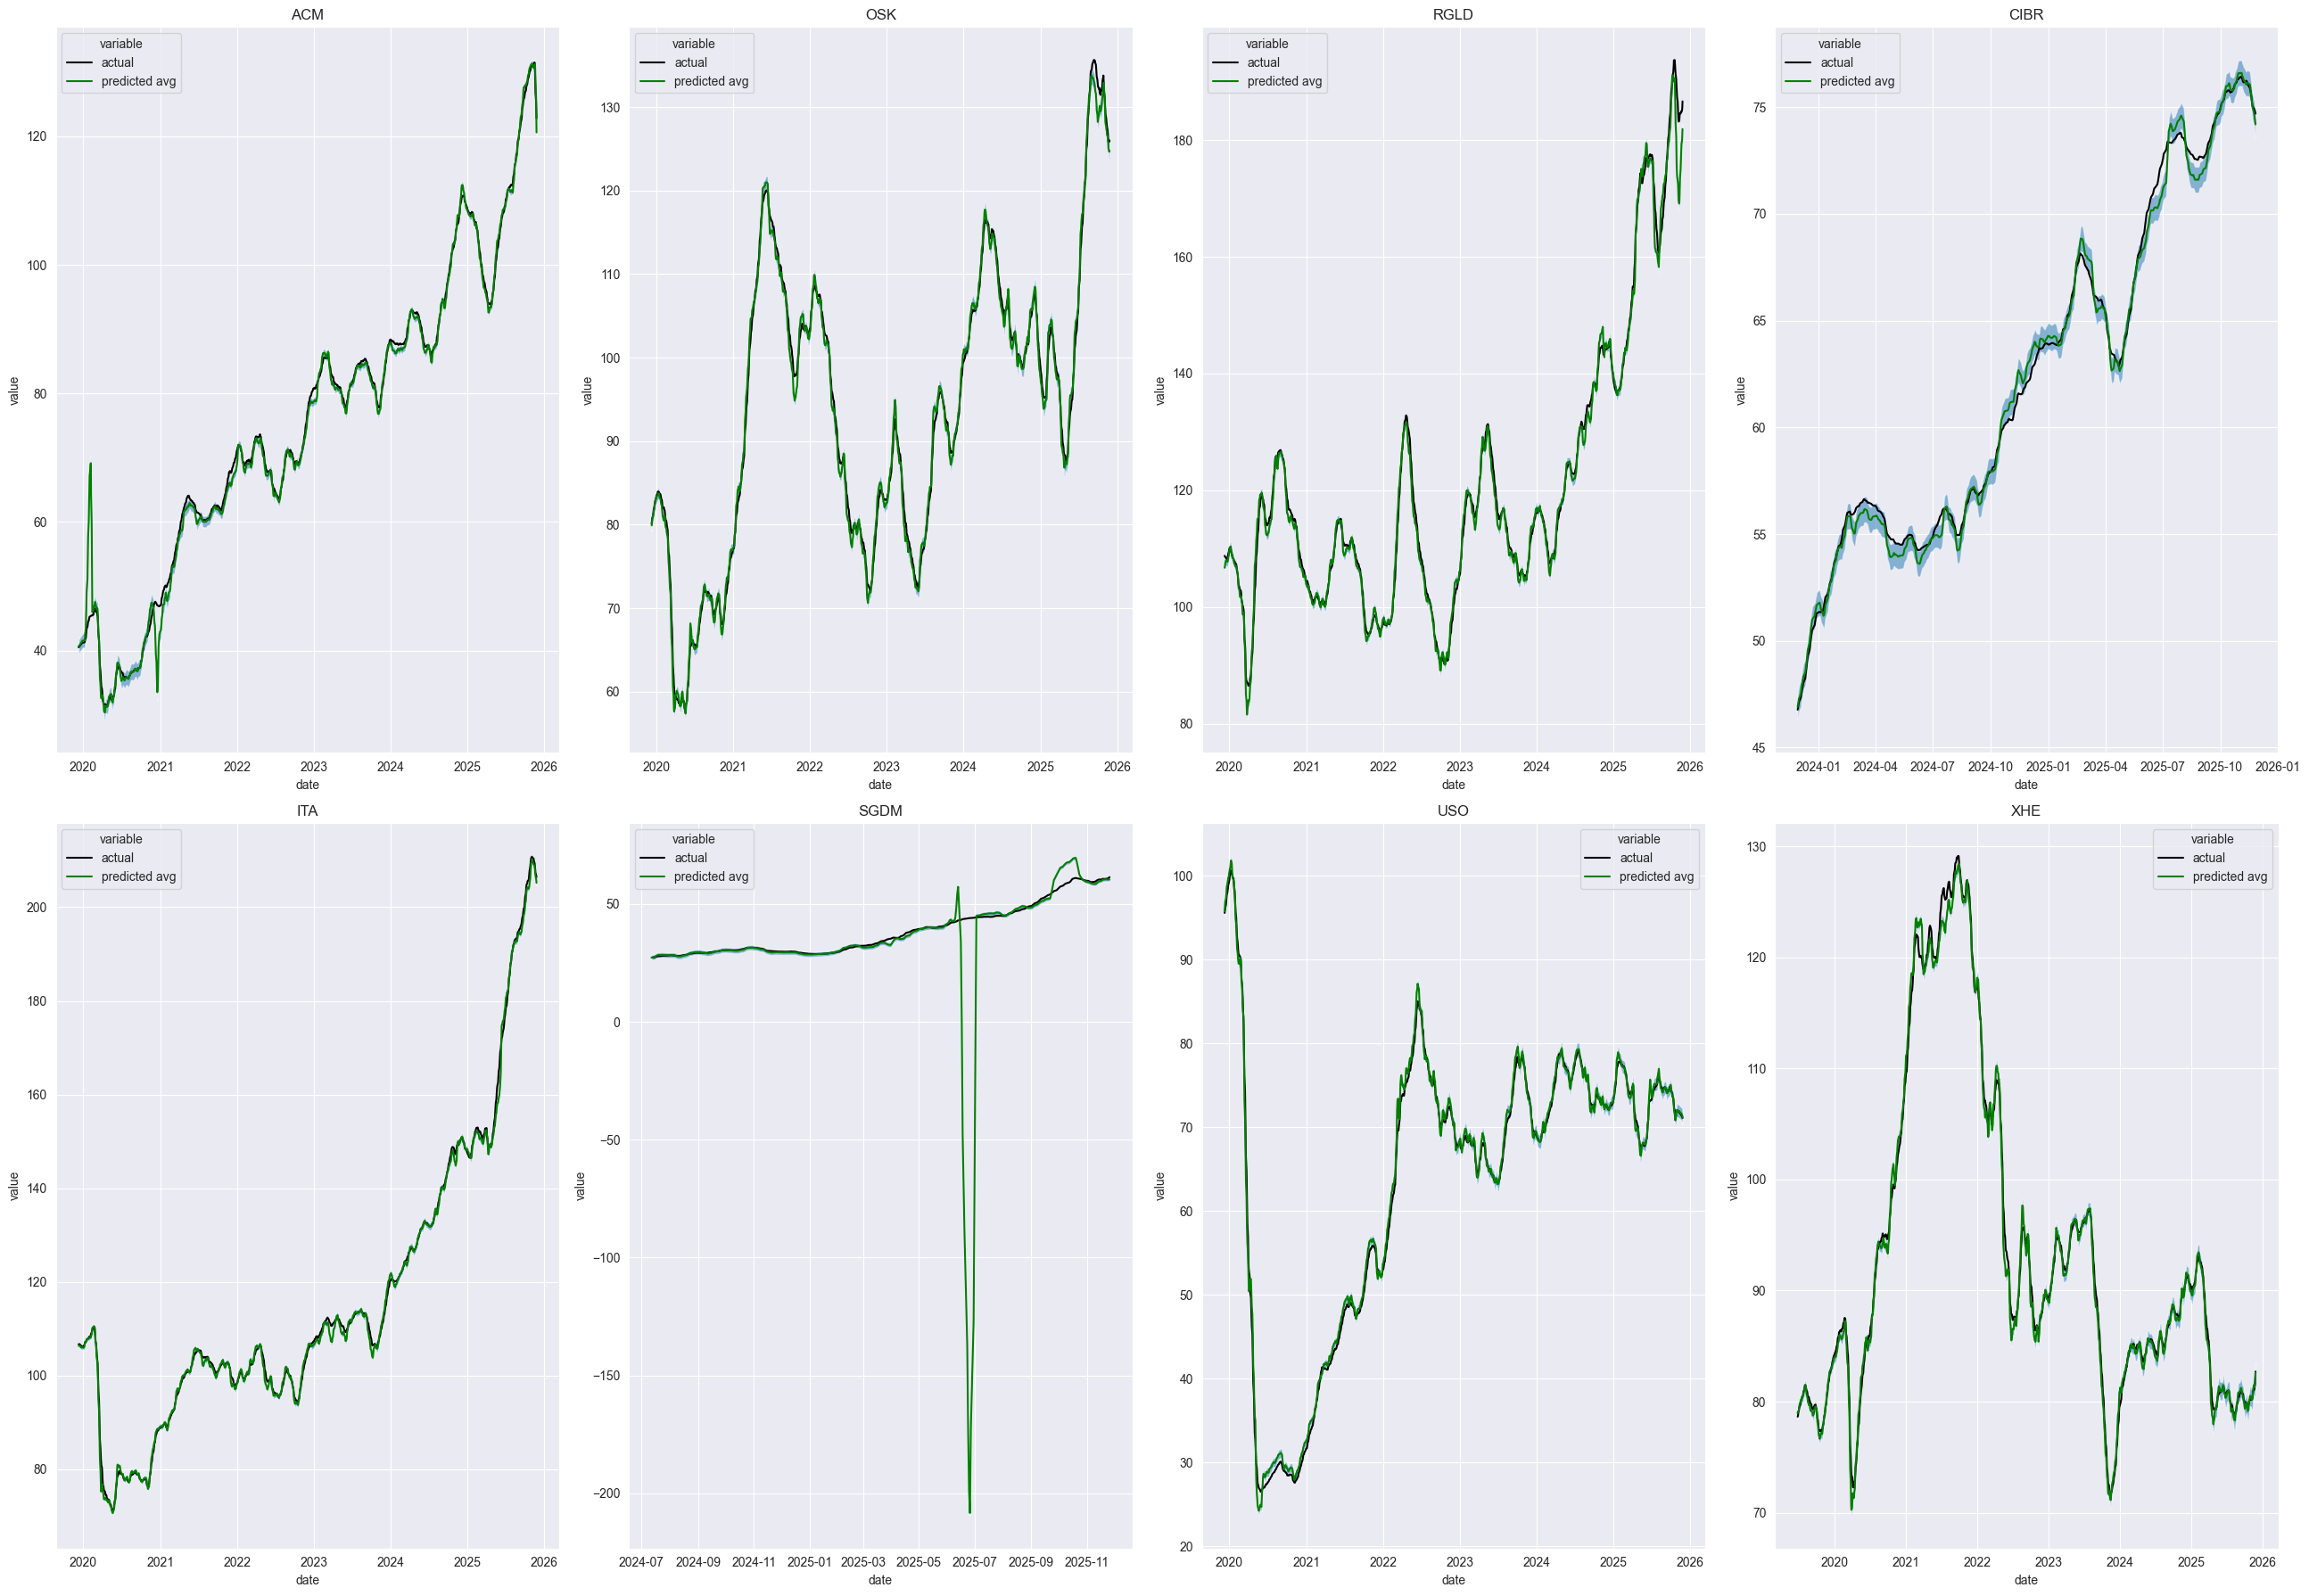

In [75]:
# plot the predicted vs actuals
len(assets.keys())
fig, axes = plt.subplots(2, 4, figsize=(26, 18))
axes = axes.flatten()
for counter, key in enumerate(assets.keys()):
    pallette = {
        'actual': 'black',
        'predicted avg': 'green'
    }
    if key == 'CIBR' or key == 'SGDM' or key == 'XHE':
        if key == 'SGDM':
            df_tmp = assets[key].iloc[500:]
        else:
            df_tmp = assets[key].iloc[100:]
    else:
        df_tmp = assets[key].iloc[1000:]
    df_melted = df_tmp.melt(id_vars=['date'], value_vars=['actual', 'predicted avg'])
    sns.lineplot(data=df_melted, x='date', y='value', hue='variable', palette=pallette, ax=axes[counter])
    axes[counter].set_title(key)
    axes[counter].fill_between(df_tmp['date'], df_tmp['predicted avg lower bound'], df_tmp['predicted avg upper bound'], alpha=0.5)
plt.tight_layout()
plt.savefig("plots/test_forecasts.png")
plt.show()

In [85]:
def metric_calculator(actual_value: float, std: float, mean: float, min: float, max: float) -> tuple[str, str]:
    """
    Output a string value if the value is within 1 std of the mean 2 standard deviations or surpasse
    Returns:

    """
    # calcualte normalized value of the prediction
    try:
        normalized_actual = (mean - actual_value) / std
    except ZeroDivisionError:
        normalized_actual = 1000
    if abs(normalized_actual) <= 1:
        return "Within 1 std", "Within sample"
    elif abs(normalized_actual) > 1 and abs(normalized_actual) <= 2:
        return "Within 2 std", "Within sample"
    elif normalized_actual > max or  normalized_actual < min:
        return "Surpasses sample boundary", "out of sample"
    elif normalized_actual == 1000:
        return "Std 0", "out of sample"
    else:
        return "Greater than 2 std", "Within sample"

def plot_sample_metrics(forecasts_dfs: dict, rows, cols, figsize) -> None:
    """
    Create a stacked bar chart of sample metrics.
    Returns:

    """
    color_palette = {
            "Within 1 std": "#002F6C",
            "Within 2 std": "#398FFF",
            "Surpasses sample boundary": "#EB2254",
        }
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()
    for i, col in enumerate(forecasts_dfs.keys()):
        # col_orginal = col
        # col = f'{col}_sample_0'
        print(forecasts_dfs[col].head())

        # Create crosstab for stacked bar chart
        ct = pd.crosstab(forecasts_dfs[col][f"predicted avg_sample_range"],
                       forecasts_dfs[col][f"predicted avg_sample_metric"])

        # Create stacked bar chart
        axes[i] = ct.plot(kind='bar', stacked=True, color=[color_palette.get(x, 'gray') for x in ct.columns], ax=axes[i])
        axes[i].set_title(f'Sample Metrics for {col}')
        axes[i].set_xlabel('Sample Range')
        axes[i].set_ylabel('Count')
        axes[i].legend(title='Sample Metric')

    plt.tight_layout()
    plt.savefig(f"plots/sample_metrics_{col}.png")
    plt.show()


def calculate_sample_metrics(forecasts_df: pd.DataFrame, dependent_varaibles: list[str], actuals_variables: list[str]):
    """
    Calculate sample metrics by creating a column for each dependent variable
    that labels predictions where the absolute value of the actual value fell within 1 std of the mean 2 standard deviations or surpasse
    the max value or the min value.
    Returns:

    """
    df_tmp = forecasts_df.iloc[14:].copy()
    # df_tmp = df_tmp.dropna()
    for col, actual_col in zip(dependent_varaibles, actuals_variables):
        col_orginal = actual_col
        # col = f'{col}_sample_0'
        df_tmp[[f"{col}_sample_metric", f"{col}_sample_range"]] = df_tmp.apply(lambda x: metric_calculator(x[f"{col_orginal}"], x[f"std"], x[f"predicted avg"], x['predicted avg lower bound'], x[f'predicted avg upper bound']),
                                                                                                     axis=1,
                                                                                                     result_type='expand'
                                                                                                     )
    return df_tmp

In [76]:
sample_metrics = {}
for asset in assets.keys():
    sample_metrics[asset] = calculate_sample_metrics(assets[asset], ['predicted avg'], ['actual'])

sample_metrics['USO'].head()

,date,actual_value,prediction,std,best_kernel,best_alpha,retrain,actual,predicted,predicted upper bound,predicted lower bound,predicted avg,predicted avg upper bound,predicted avg lower bound,predicted avg_sample_metric,predicted avg_sample_range
14,2016-01-11,[[89.888571088826]],[86.62522214863469],0.118089,Sum,None,False,89.888571,86.625222,87.279490,85.970954,88.152687,88.806955,87.498419,Surpasses sample boundary,out of sample
15,2016-01-12,[[88.82221170311799]],[85.55201323165807],0.118089,Sum,None,False,88.822212,85.552013,86.206282,84.897745,87.373382,88.027651,86.719114,Surpasses sample boundary,out of sample
16,2016-01-13,[[87.78335941392994]],[84.4958226292531],0.118089,Sum,None,False,87.783359,84.495823,85.150091,83.841554,86.471161,87.125430,85.816893,Surpasses sample boundary,out of sample
17,2016-01-14,[[86.88378760257257]],[83.48156396042597],0.118089,Sum,None,False,86.883788,83.481564,84.135832,82.827296,85.516449,86.170717,84.862181,Surpasses sample boundary,out of sample
18,2016-01-15,[[85.81515612465333]],[82.64207256910882],0.118089,Sum,None,False,85.815156,82.642073,83.296341,81.987804,84.559339,85.213607,83.905071,Surpasses sample boundary,out of sample


         date            actual_value            prediction       std  \
14 2016-01-11  [[28.654539936575457]]  [28.099757973697262]  0.335634   
15 2016-01-12   [[28.52736033739588]]  [27.825901132420476]  0.335634   
16 2016-01-13   [[28.37042052980274]]  [27.805912975232985]  0.335634   
17 2016-01-14   [[28.21178067872739]]   [27.51786806241857]  0.335634   
18 2016-01-15   [[28.01794212010108]]  [27.323750313322098]  0.335634   

   best_kernel best_alpha  retrain     actual  predicted  \
14         Sum       None    False  28.654540  28.099758   
15         Sum       None    False  28.527360  27.825901   
16         Sum       None    False  28.370421  27.805913   
17         Sum       None    False  28.211781  27.517868   
18         Sum       None    False  28.017942  27.323750   

    predicted upper bound  predicted lower bound  predicted avg  \
14              29.406660              26.792856      28.656341   
15              29.132804              26.518999      28.408079   

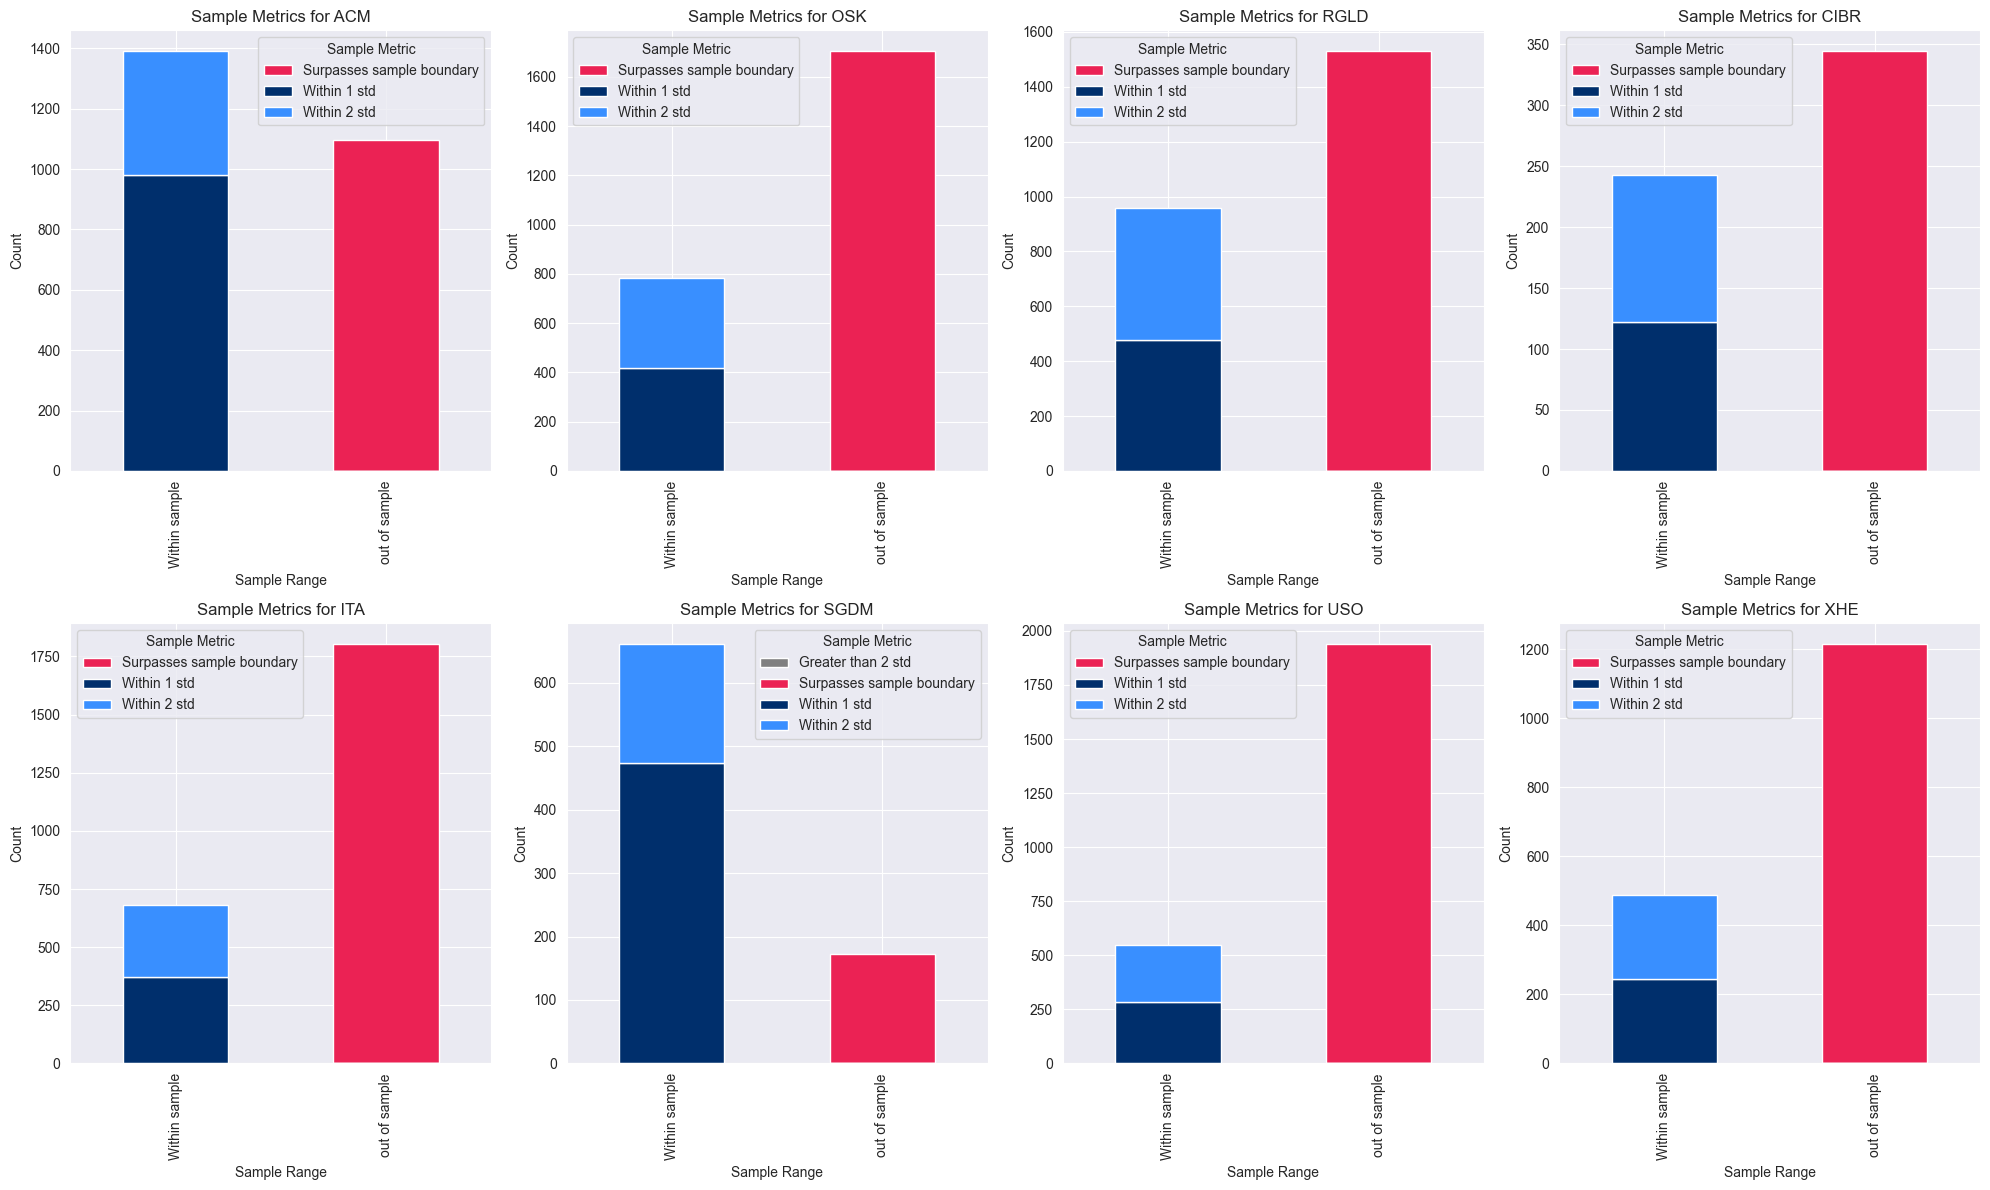

In [86]:
plot_sample_metrics(sample_metrics, rows=2, cols=4, figsize=(20, 12))

In [89]:
for ticker in assets.keys():
    difference = np.abs(assets[ticker]['actual'].shift(1) - assets[ticker]['actual'].shift(-6))
    print(f"Ticker {ticker}:\tmean:{difference.mean()}\tmedian:{difference.median()}\tstd:{difference.std()}")
print(f"\n")
for ticker in assets.keys():
    difference = np.abs(assets[ticker]['predicted avg'].shift(1) - assets[ticker]['predicted avg'].shift(-6))
    print(f"Ticker {ticker}:\tmean:{difference.mean()}\tmedian:{difference.median()}\tstd:{difference.std()}")

Ticker ACM:	mean:0.8948500070229185	median:0.6341951413203475	std:0.8546903324897673
Ticker OSK:	mean:1.5660527504388242	median:1.2867727491116767	std:1.2311274037275257
Ticker RGLD:	mean:1.9004977630896536	median:1.427730623464825	std:1.636361823970336
Ticker CIBR:	mean:0.6653323298876455	median:0.5809032752639638	std:0.4810781802167933
Ticker ITA:	mean:1.1567887354347932	median:0.828902975741542	std:1.2507518914473803
Ticker SGDM:	mean:0.624161006099577	median:0.5061321941863852	std:0.5271478966435017
Ticker USO:	mean:1.4368724580660963	median:1.0377725099558859	std:1.5389714752802852
Ticker XHE:	mean:1.178077560901183	median:0.8693836153938506	std:1.0379756561526983


Ticker ACM:	mean:1.1986908896323203	median:0.7121983999983286	std:1.7177223324092974
Ticker OSK:	mean:1.8423111003672947	median:1.4530938519251322	std:1.529493151307555
Ticker RGLD:	mean:2.257407953640765	median:1.675332841211727	std:2.174501969006076
Ticker CIBR:	mean:0.8121612069184174	median:0.6639958623192932	std:0

In [5]:
prediction_var = 'predicted'
# calculate the cumulative returns
def calc_bets_long(signal: str, actual_return: float):
        if signal == 'buy':
            return actual_return
        else:
            return 0.0

def calc_bets_hedged(signal: str, actual_return: float):
    if signal == 'buy':
        return actual_return
    elif signal == 'hold':
        return 0.0
    else:
        return -actual_return

def buy_sell_signal2(x):
    if x >= 0.02:
        return 'buy'
    elif x <= -0.02:
        return 'sell'
    else:
        return 'hold'


for key in assets.keys():
    actual_results = pd.read_parquet(f'data/{key}.parquet')
    actual_results['date'] = actual_results.index
    actual_results['log_return'] = np.log(actual_results['Adj Close'].shift(-6) / actual_results['Adj Close'].shift(1))
    actual_results["30 Day Avg"] = actual_results["Adj Close"].ewm(span=30, adjust=False).mean()
    actual_results['Lag 1'] = actual_results['30 Day Avg'].shift(1)

    assets[key] = assets[key].merge(actual_results[['date', 'Adj Close', 'log_return', 'Lag 1']], on='date', how='left')

    assets[key]['predicted return'] = np.log(assets[key][prediction_var] / assets[key]['Lag 1'])
    assets[key]['buy sell signal'] = assets[key]['predicted return'].apply(lambda x: 'buy' if x >= 0 else 'sell')

    assets[key]['buy sell signal2'] = assets[key]['predicted return'].apply(lambda x: buy_sell_signal2(x=x))


    assets[key]['bets long'] = assets[key].apply(lambda x: calc_bets_long(signal=x['buy sell signal'], actual_return=x['log_return']), axis=1)
    assets[key]['bets long2'] = assets[key].apply(lambda x: calc_bets_long(signal=x['buy sell signal2'], actual_return=x['log_return']), axis=1)

    assets[key]['bets hedged'] = assets[key].apply(lambda x: calc_bets_hedged(signal=x['buy sell signal'], actual_return=x['log_return']), axis=1)
    assets[key]['bets hedged2'] = assets[key].apply(lambda x: calc_bets_hedged(signal=x['buy sell signal2'], actual_return=x['log_return']), axis=1)

    # calculate the cumulative returns
    assets[key]['bets long cumulative'] = assets[key]['bets long'].cumsum()
    assets[key]['bets long cumulative2'] = assets[key]['bets long2'].cumsum()

    assets[key]['bets hedged cumulative'] = assets[key]['bets hedged'].cumsum()
    assets[key]['bets hedged cumulative2'] = assets[key]['bets hedged2'].cumsum()

    assets[key]['cumulative_hold'] = assets[key]['log_return'].cumsum()

assets['USO'].head()

/Users/mma0277/Documents/Development/mean_reversion_strategy/mvr/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,date,actual_value,prediction,best_kernel,best_alpha,retrain,actual,predicted,predicted avg,Adj Close,...,buy sell signal2,bets long,bets long2,bets hedged,bets hedged2,bets long cumulative,bets long cumulative2,bets hedged cumulative,bets hedged cumulative2,cumulative_hold
0,2015-12-18,[[99.02202591369317]],[94.11125228940247],Sum,None,True,99.022026,94.111252,NaN,85.279999,...,sell,0.0,0.0,-0.047282,-0.047282,0.0,0.0,-0.047282,-0.047282,0.047282
1,2015-12-21,[[98.13544351792568]],[93.12903173561],Sum,None,False,98.135444,93.129032,NaN,85.279999,...,sell,0.0,0.0,-0.025013,-0.025013,0.0,0.0,-0.072295,-0.072295,0.072295
2,2015-12-22,[[97.3628344949698]],[92.25919030554675],Sum,None,False,97.362834,92.259190,NaN,86.160004,...,sell,0.0,0.0,-0.031397,-0.031397,0.0,0.0,-0.103691,-0.103691,0.103691
3,2015-12-23,[[96.89297432310433]],[91.57072236901058],Sum,None,False,96.892974,91.570722,NaN,90.080002,...,sell,0.0,0.0,-0.019311,-0.019311,0.0,0.0,-0.123002,-0.123002,0.123002
4,2015-12-24,[[96.4740728523156]],[91.27732842626551],Sum,None,False,96.474073,91.277328,NaN,90.400002,...,sell,0.0,0.0,0.054758,0.054758,0.0,0.0,-0.068244,-0.068244,0.068244


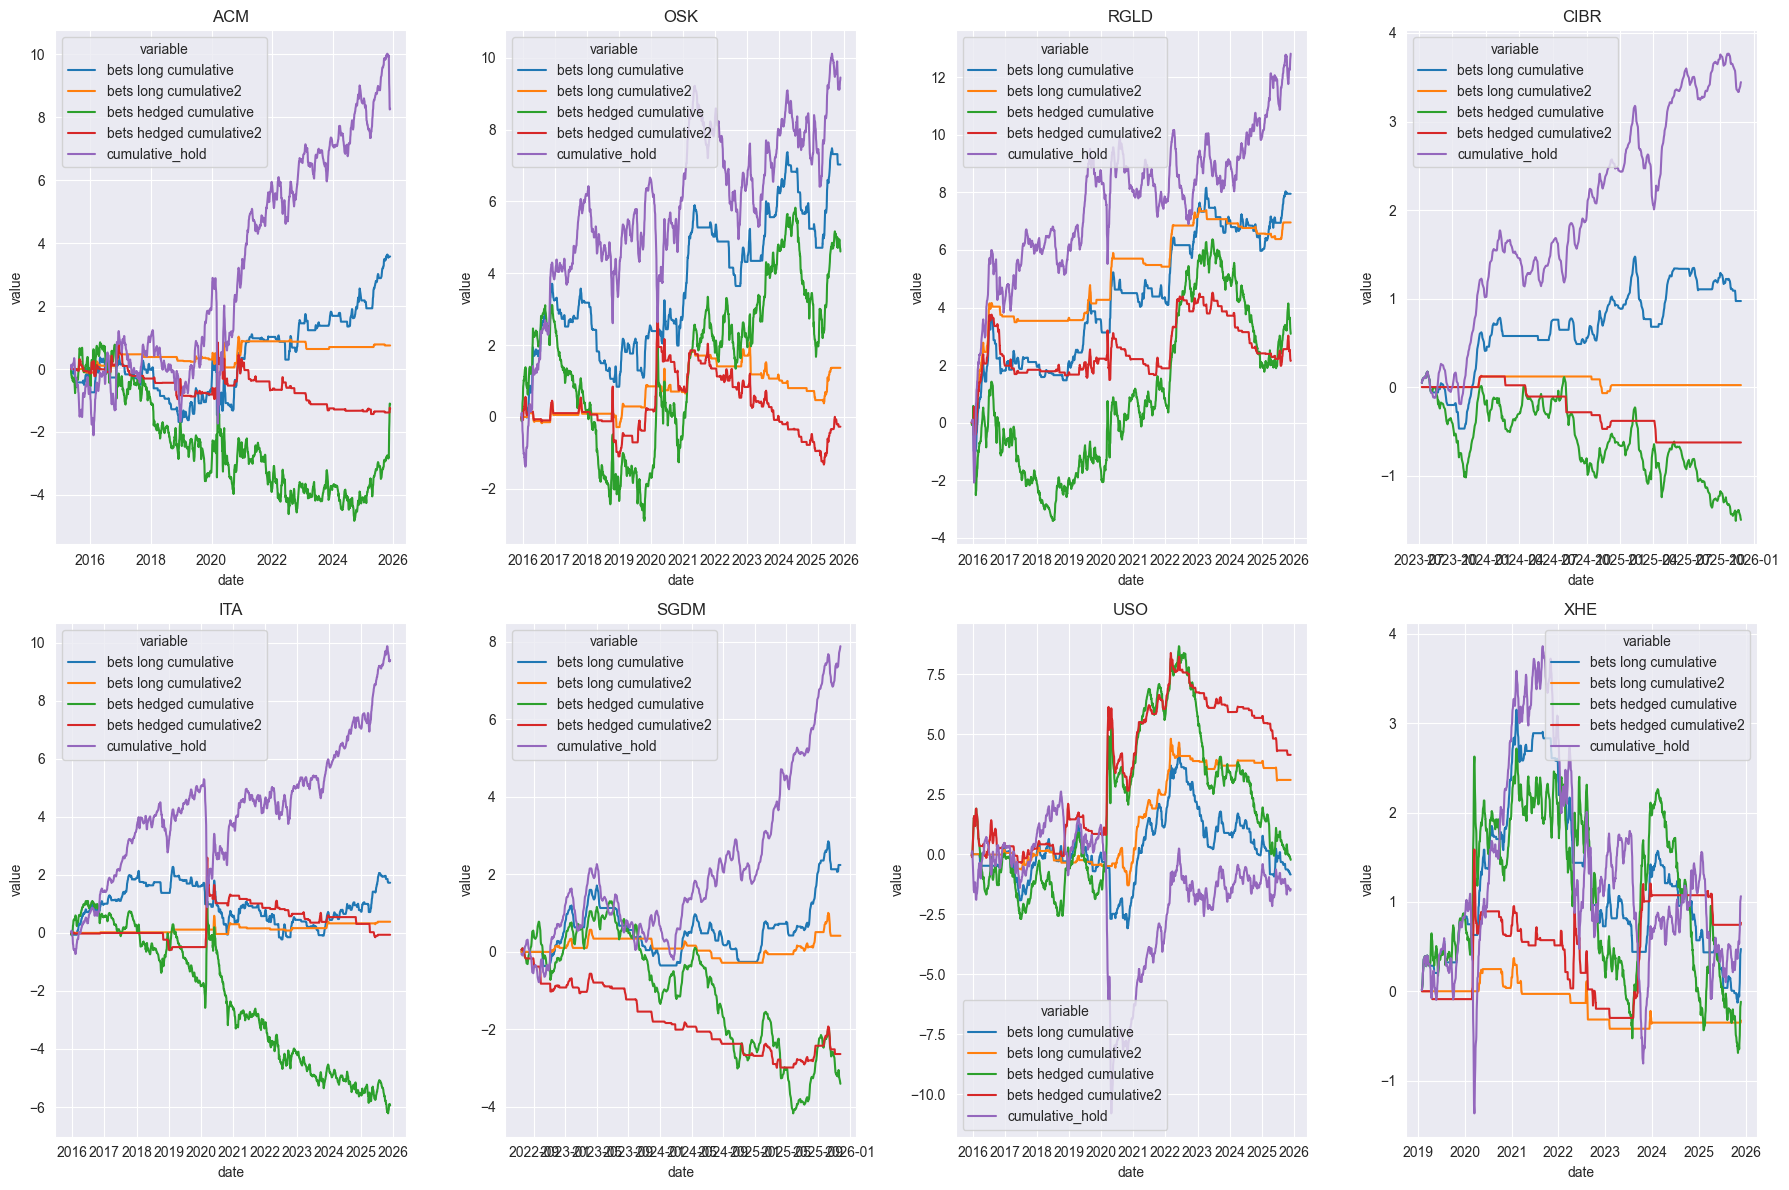

In [43]:
plot_cols = ['bets long cumulative', 'bets long cumulative2', 'bets hedged cumulative', 'bets hedged cumulative2', 'cumulative_hold']

fig, axes = plt.subplots(2, 4, figsize=(18, 12))
axes = axes.flatten()
for counter, key in enumerate(assets.keys()):
    df_melted = assets[key].melt(id_vars=['date'], value_vars=plot_cols)
    sns.lineplot(data=df_melted, x='date', y='value', hue='variable', ax=axes[counter])
    axes[counter].set_title(key)
plt.tight_layout()
plt.show()


In [44]:
# calcualte the risk adjusted returns of the predictions
adj_cols = [
    'bets long cumulative simple', 'bets long cumulative2 simple', 'bets hedged cumulative simple', 'bets hedged cumulative2 simple', 'cumulative_hold simple',
    'bets long cumulative simple std', 'bets long cumulative2 simple std', 'bets hedged cumulative simple std', 'bets hedged cumulative2 simple std', 'cumulative_hold simple std', 'date'
]

risk_free = pd.read_parquet('data/risk_free_rate.parquet')
risk_free['TB3MS'] = risk_free['TB3MS'] / 100
risk_free_assets = {}

for key in assets.keys():
    assets[key]['bets long cumulative simple'] = assets[key]['bets long cumulative'].apply(lambda x: math.exp(x) - 1)
    assets[key]['bets long cumulative2 simple'] = assets[key]['bets long cumulative2'].apply(lambda x: math.exp(x) - 1)

    assets[key]['bets hedged cumulative simple'] = assets[key]['bets hedged cumulative'].apply(lambda x: math.exp(x) - 1)
    assets[key]['bets hedged cumulative2 simple'] = assets[key]['bets hedged cumulative2'].apply(lambda x: math.exp(x) - 1)

    assets[key]['cumulative_hold simple'] = assets[key]['cumulative_hold'].apply(lambda x: math.exp(x) - 1)

    # calculate the running std
    assets[key]['bets long cumulative simple std'] = assets[key]['bets long cumulative simple'].expanding().std()
    assets[key]['bets long cumulative2 simple std'] = assets[key]['bets long cumulative2 simple'].expanding().std()

    assets[key]['bets hedged cumulative simple std'] = assets[key]['bets hedged cumulative simple'].expanding().std()
    assets[key]['bets hedged cumulative2 simple std'] = assets[key]['bets hedged cumulative2 simple'].expanding().std()

    assets[key]['cumulative_hold simple std'] = assets[key]['cumulative_hold simple'].expanding().std()
    ticker_risk_free = risk_free.merge(assets[key][adj_cols], how='inner', on='date')
    ticker_risk_free = ticker_risk_free.dropna()
    adj_cols2 = [
    'bets long cumulative simple', 'bets long cumulative2 simple', 'bets hedged cumulative simple', 'bets hedged cumulative2 simple', 'cumulative_hold simple'
    ]
    for col in adj_cols2:
        ticker_risk_free[f'{col} sharpe'] = np.where(ticker_risk_free[f'{col} std'] == 0, 0, (ticker_risk_free[col] - ticker_risk_free['TB3MS'])  / ticker_risk_free[f'{col} std'])

    risk_free_assets[key] = ticker_risk_free

# assets[key][['predicted return', 'predicted', 'Lag 1', 'log_return']]

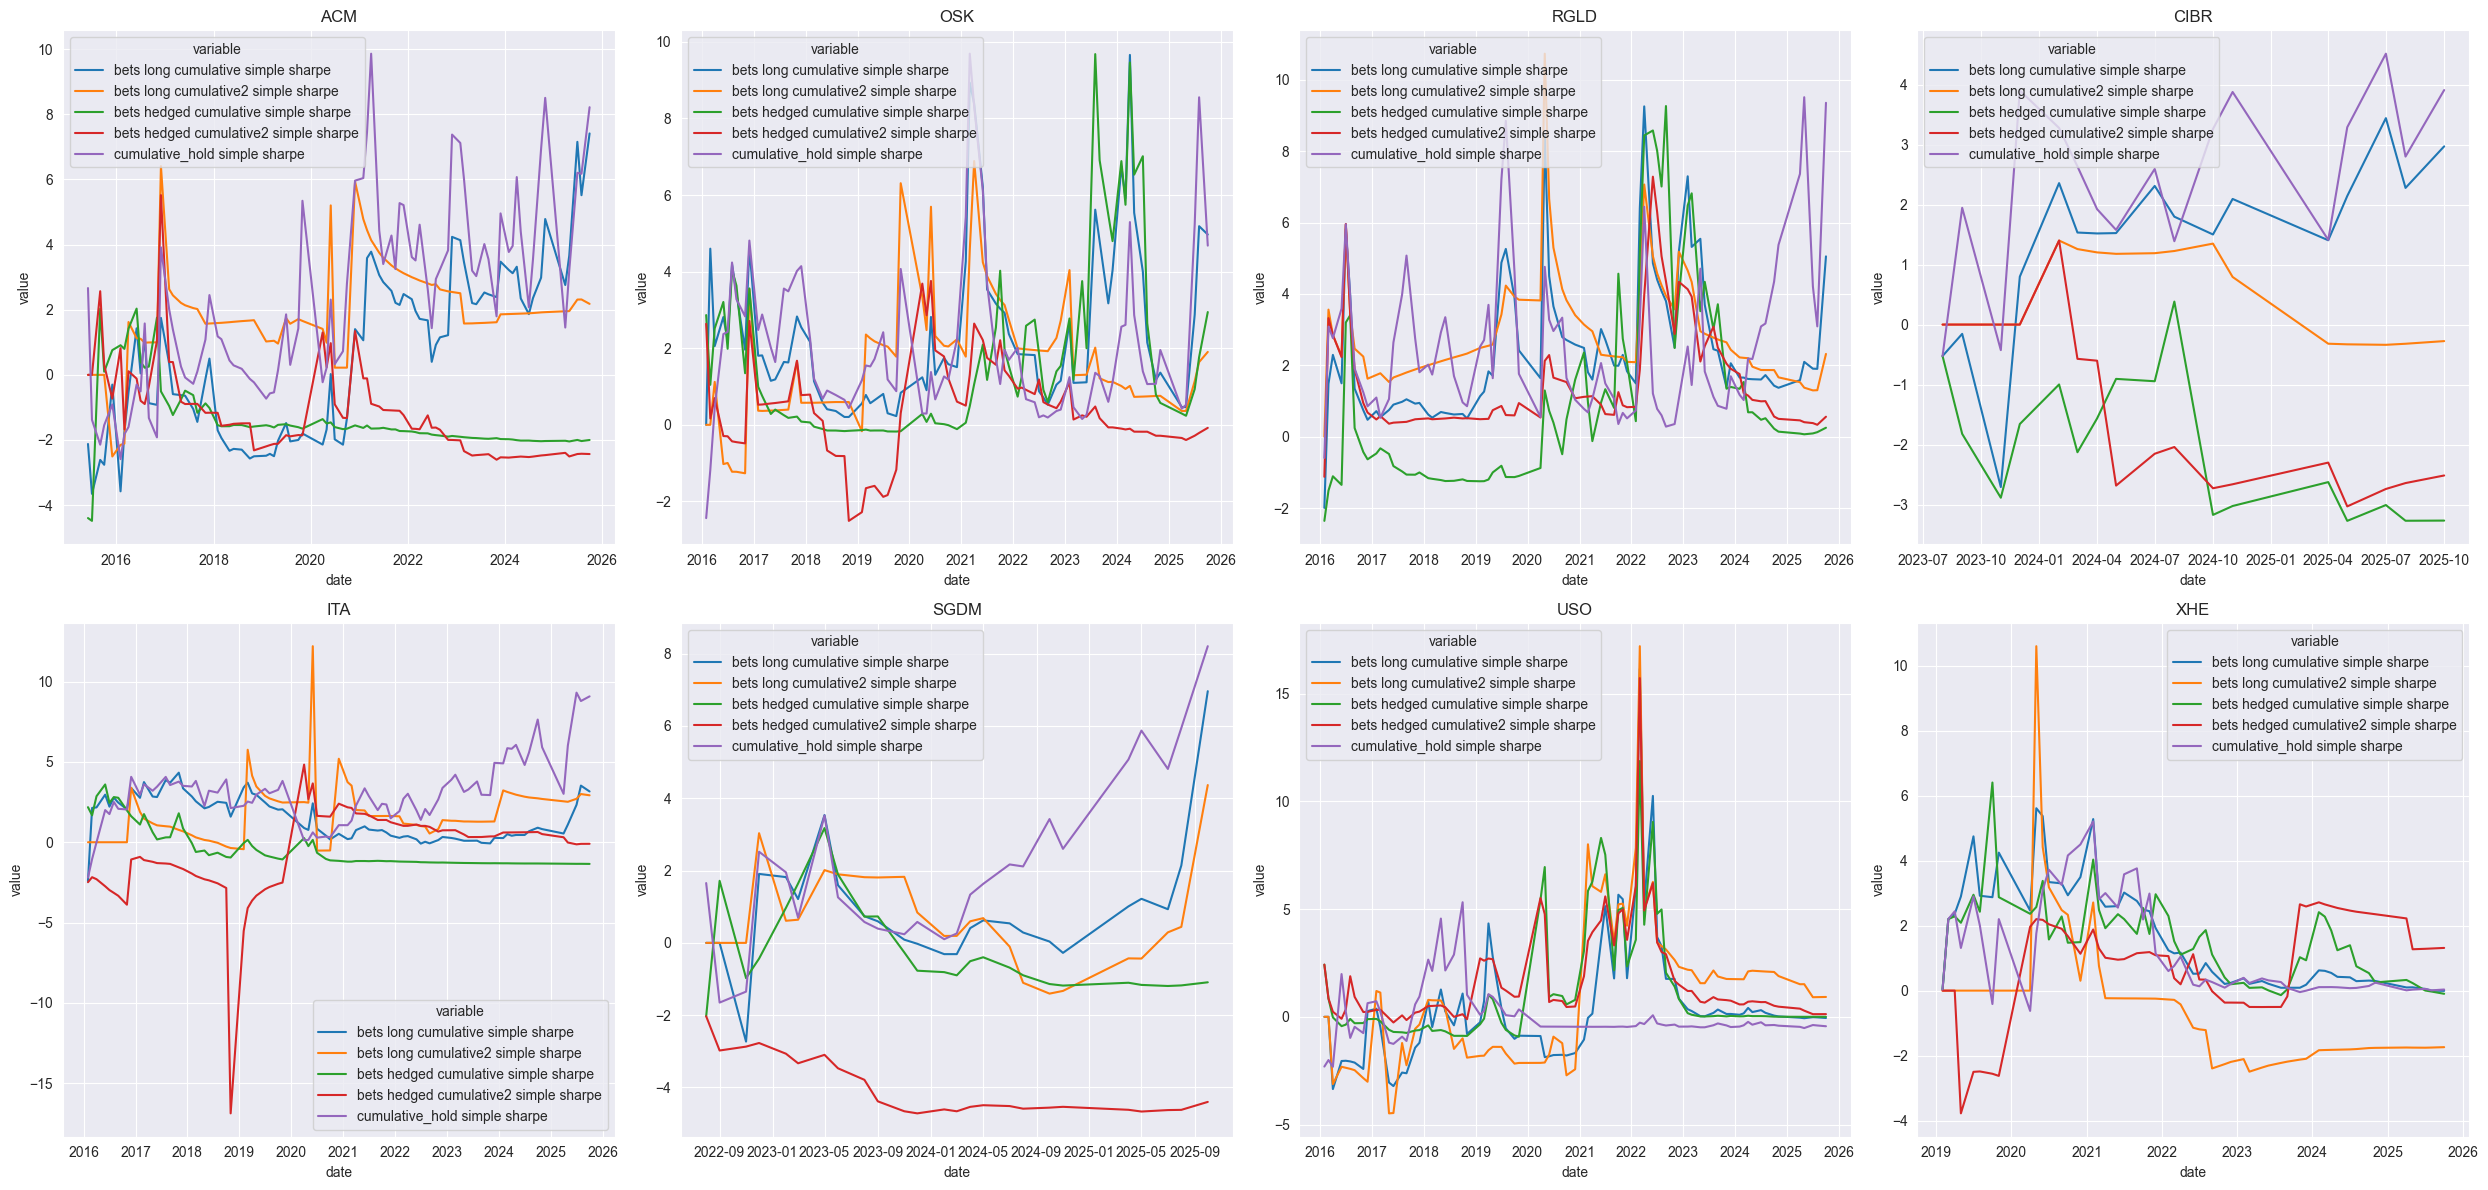

In [45]:
adj_cols3 = [
    'bets long cumulative simple sharpe', 'bets long cumulative2 simple sharpe', 'bets hedged cumulative simple sharpe', 'bets hedged cumulative2 simple sharpe', 'cumulative_hold simple sharpe'
    ]
fig, axes = plt.subplots(2, 4, figsize=(25, 12))
axes = axes.flatten()

for counter, key in enumerate(risk_free_assets.keys()):
    # melt the data
    df_melted = risk_free_assets[key].melt(id_vars=['date'], value_vars=adj_cols3)
    sns.lineplot(data=df_melted, x='date', y='value', hue='variable', ax=axes[counter])
    axes[counter].set_title(key)
plt.tight_layout()
plt.show()

In [53]:
# get the rankings for each ticker
adj_cols3 = [
    'bets long cumulative simple sharpe', 'bets long cumulative2 simple sharpe', 'bets hedged cumulative simple sharpe', 'bets hedged cumulative2 simple sharpe', 'cumulative_hold simple sharpe'
    ]
records = []
for key in risk_free_assets.keys():
    max_date = risk_free_assets[key]['date'].max()
    record = risk_free_assets[key][risk_free_assets[key]['date'] == max_date][adj_cols3].to_dict(orient='records')[0]
    record['ticker'] = key
    records.append(record)

# create the dataframe
df_metrics = pd.DataFrame(records)
df_metrics



,bets long cumulative simple sharpe,bets long cumulative2 simple sharpe,bets hedged cumulative simple sharpe,bets hedged cumulative2 simple sharpe,cumulative_hold simple sharpe,ticker
0,7.413864,2.179870,-2.000273,-2.431448,8.219593,ACM
1,4.968643,1.903286,2.944301,-0.078639,4.679103,OSK
2,5.053338,2.320071,0.252019,0.560571,9.356410,RGLD
3,2.970410,-0.275251,-3.266714,-2.514943,3.908603,CIBR
4,3.161485,2.923329,-1.349534,-0.097705,9.084100,ITA
5,6.962522,4.365928,-1.090323,-4.399061,8.207144,SGDM
6,-0.054192,0.922247,-0.000039,0.125273,-0.437088,USO
7,-0.006563,-1.739729,-0.096989,1.314925,0.034561,XHE


In [55]:
# melt the data and get the rankings
df_metrics_melted = df_metrics.melt(id_vars=['ticker'], value_vars=adj_cols3)

for group, group_df in df_metrics_melted.groupby(['ticker']):
    print(f"{group}: \n{group_df.sort_values('value', ascending=False)} \n")

('ACM',): 
   ticker                               variable     value
32    ACM          cumulative_hold simple sharpe  8.219593
0     ACM     bets long cumulative simple sharpe  7.413864
8     ACM    bets long cumulative2 simple sharpe  2.179870
16    ACM   bets hedged cumulative simple sharpe -2.000273
24    ACM  bets hedged cumulative2 simple sharpe -2.431448 

('CIBR',): 
   ticker                               variable     value
35   CIBR          cumulative_hold simple sharpe  3.908603
3    CIBR     bets long cumulative simple sharpe  2.970410
11   CIBR    bets long cumulative2 simple sharpe -0.275251
27   CIBR  bets hedged cumulative2 simple sharpe -2.514943
19   CIBR   bets hedged cumulative simple sharpe -3.266714 

('ITA',): 
   ticker                               variable     value
36    ITA          cumulative_hold simple sharpe  9.084100
4     ITA     bets long cumulative simple sharpe  3.161485
12    ITA    bets long cumulative2 simple sharpe  2.923329
28    ITA  bets he